In [1]:
from Training import ResNet50,Predict_with_model

### Introduction

### No Ai was used in the writing of this assignment

In this competition, we are provided retinal image. The images have been graded according to the severity of diabetic retinopathy (DR) on the following scale:

| Label | Severity Level     | Description                          |
|-------|------------------|--------------------------------------|
| 0     | No DR            | No signs of diabetic retinopathy     |
| 1     | Mild             | Early signs                          |
| 2     | Moderate         | More extensive abnormalities         |
| 3     | Severe           | Significant retinal damage           |
| 4     | Proliferative DR | Advanced stage with neovascularization |

Yet, the data includes noise and imperfections. Images may be blurry, underexposed, overexposed, or contain artifacts, and labels may not always be perfectly consistent.

### Final Project

Thus, this project involves building an automated image classification pipeline accurately predicting the severity level of the disease from retinal images.

### Model Choice

For this project, we have elected to use a Residual Network (ResNet) architecture. 
Residual networks are well-suited for image classification tasks due to their skip connections, which help mitigate the vanishing gradient problem. This allows the network to learn rich hierarchical features from retinal images.

### Model Choice

We selected **ResNet50** and an **Model Efficient B3** for this project.

ResNet architectures differ in how their building blocks are structured. These models use *bottleneck blocks* first reduce the number of channels, process the features, and then expand them back. This design is chosen as to reduce computational cost while allowing.

This Bottleneck structure enables learning richer features compared to shallower models. On the other hand, Efficient ResNet variants build on the original ResNet idea but optimize performance further through improved scaling and parameter efficiency.

The choice was influenced from Ben Trevett notebook

**Code structure**

### Code Structure Overview

The project is organized into modular components to ensure clarity.

**Loader Class**  
The `Loader` class is responsible for handling dataset access and organization. It reads image paths, associates them with labels. This class serves as the entry point, ensuring that samples are consistently and efficiently retrieved during training and evaluation.

**Preprocessing Class**  
The `Preprocessing` class (implemented as a child class) handles all data transformation steps. This includes resizing images, and normalization.

**ResNet50 Model**  
The `ResNet50` component defines the deep learning model used for classification. It leverages a pretrained ResNet50 architecture adapting the final layers to output predictions for the five diabetic retinopathy classes.

**Predict_with_model**  
The `Predict_with_model` module is used for inference. It loads the trained ResNet50 model from saved weights and applies it to new or unseen retinal images. This component handles the end-to-end prediction pipeline, including applying the same preprocessing steps and outputting the final predicted class.

### Data Loading and Preprocessing Pipeline

The dataset is loaded through the `ResNet50` class, which acts as the central entry point for the entire pipeline. This class internally calls both the `Loader` and `Preprocessing` classes to ensure a clean separation between data handling and model definition.

**1. Data Loading (ResNet50 → Loader + Preprocessing)**  
The `ResNet50` class initializes the dataset pipeline by invoking the `Loader` class. The `Loader` is responsible for reading image paths, associating each image with its corresponding label, and preparing structured input for training and evaluation.

Once the data is loaded, it is passed to the `Preprocessing` class for transformation.

**2. Ben Graham Preprocessing**  
The first transformation applied is the Ben Graham preprocessing technique. This step enhances image quality by improving contrast and removing noise, making subtle retinal features more visible. It is particularly useful for medical images where fine-grained details are critical for classification.

**3. CLAHE Transformation**  
Parralel to Ben Graham preprocessing, Contrast Limited Adaptive Histogram Equalization (CLAHE) is applied. This technique further improves local contrast in the image while preventing over-amplification of noise. It helps highlight important retinal structures such as blood vessels and lesions, which are essential for detecting diabetic retinopathy.

Together, these preprocessing steps ensure that the input images are standardized and enhanced before being passed into the ResNet50 model for training and inference.

Processing methods will be further detailed


## First obsevations

During the first observations of the datasets, one has observed that the pannel was heavily imbalanced, with a majority of images being 0



In [2]:
resnet_graham = ResNet50('Ben_Graham')

Torch Version: 2.5.1+cu121
GPU Available with Cuda: cuda
NVIDIA GeForce RTX 4060 Laptop GPU
Number of GPUs available: 1
Subset class distribution:
label
0    700
1    700
2    700
3    700
4    700
Name: count, dtype: int64
Total subset size: 3500
set() resize(s) needed
Loading Class successfully loaded

The dataset is balanced, therefore all class have the same weights):
Train DataLoader successfully loaded: 87 batches x 32 = 2784 samples/epoch
Val DataLoader: 22 batches x 32
Build ResNet50
Build EfficientNet-B3
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=512, bias=True)
  (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU(inplace=True)
  (4): Dropout(p=0.25, inplace=False)
  (5): Linear(in_features=512, out_features=256, bias=True)
  (6): ReLU(inplace=True)
  (7): Linear(in_features=256, out_features=5, bias=True)
)
Total parameters: 24,690,757
Trainable parameters: 24,690,757

=== Effici

In [ ]:
resnet_clahe= ResNet50('Clahe')


## First obsevations

During the first observations of the datasets, one has observed that the pannel was heavily imbalanced, with a majority of images being 0

Images are also resized to 224 times 224, recommended for image classification

Next, we observe images within the sample

TypeError: 'NoneType' object is not callable

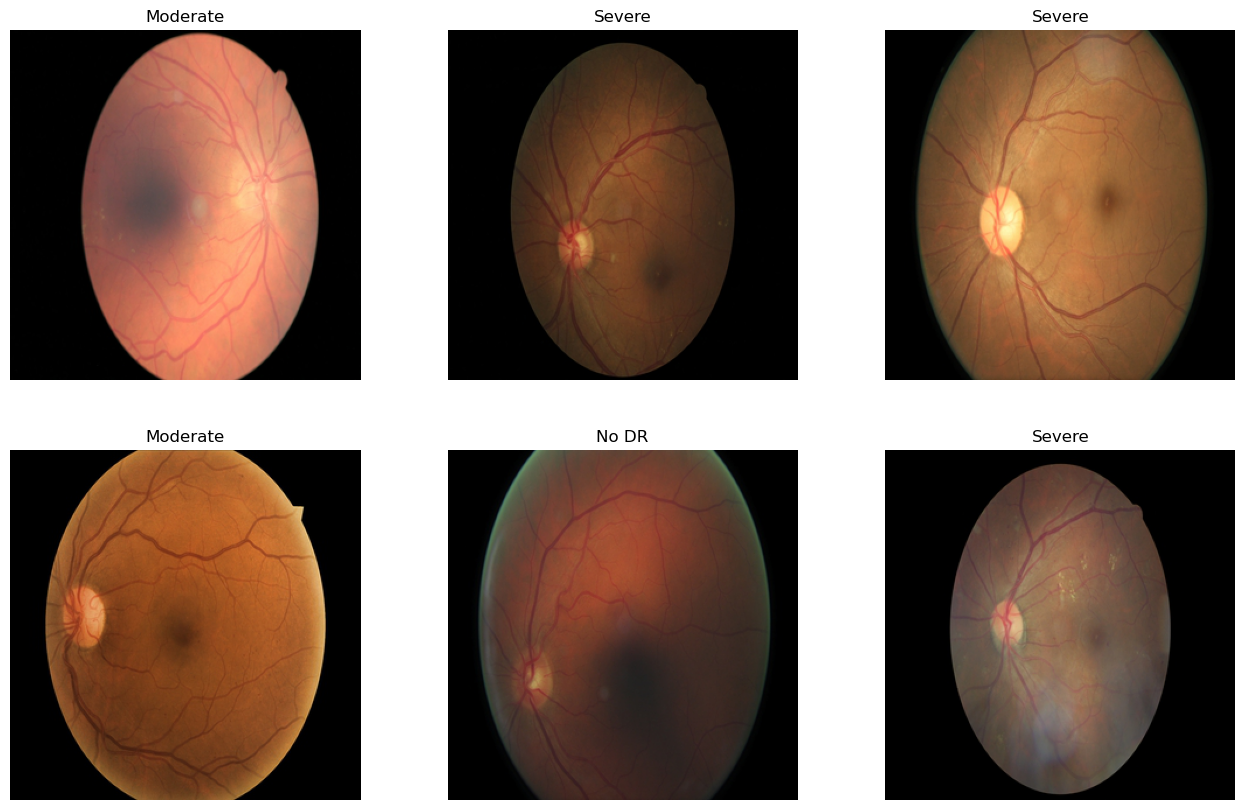

In [ ]:
resnet_graham.visualize_random_sample()

TypeError: 'NoneType' object is not callable

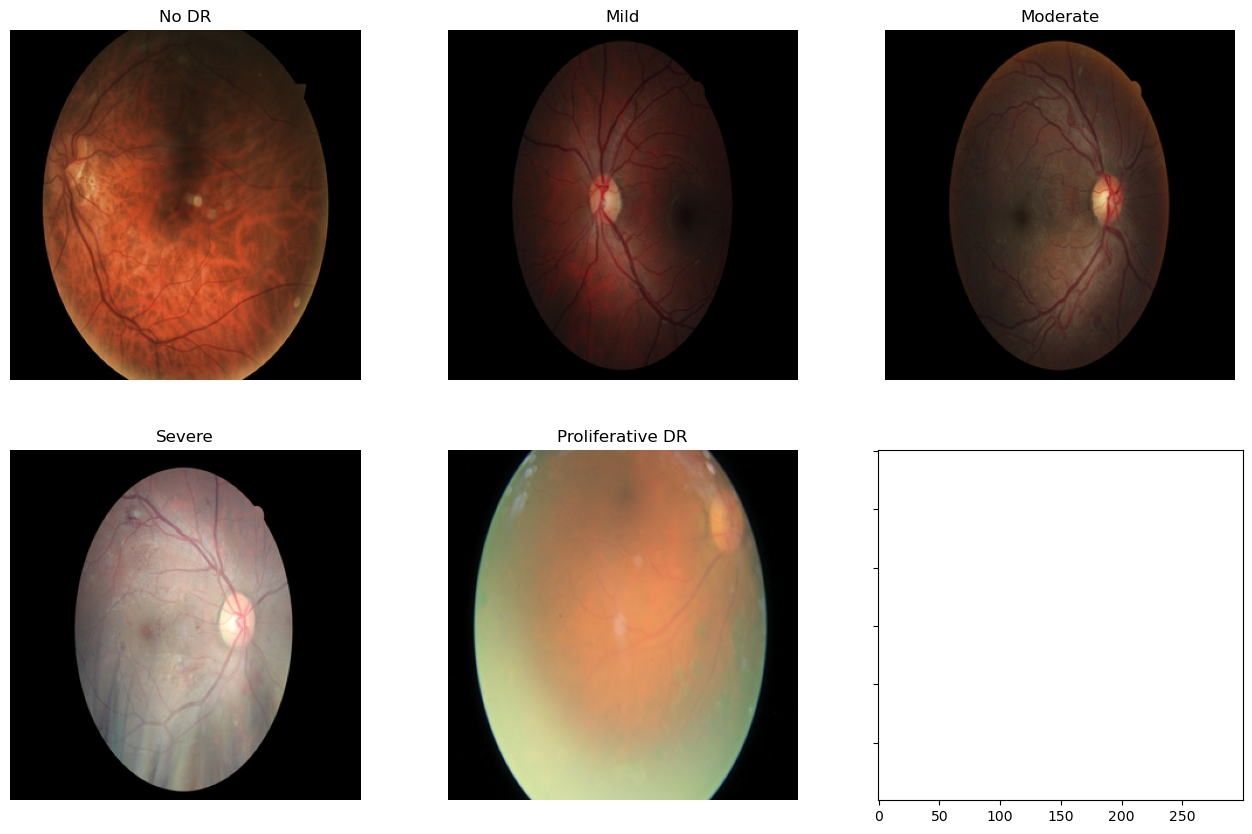

In [ ]:
resnet_graham.visualize_sample_cat()

We observe that for Label 0, healthy retina with no visible signs of disease. Blood vessels appear normal, but hey are difficultly distinguishable from mild images.

However, for moderate to proliferative DR, we observe significant retinal damage with venous abnormalities and white patches.
Most advanced stage are characterized by abnormal new blood vessel (new reds lines on the photo) and large white patches

**Dataset Rebalanced**
The resampling process is used to handle class imbalance in the dataset by limiting the number of samples per class.

The code iterates through each of the 5 diabetic retinopathy classes (0 to 4). For each class:

1. It selects all samples belonging to that class.
2. It determines the number of samples to keep using:
   - The smaller value between:
     - The number of available samples in that class  
     - A predefined limit `max_per_class`
3. It randomly samples `n_sample` images from that class using a fixed `random_state=42` to ensure reproducibility.
4. Each sampled subset is stored in a list.

After processing all classes, the subsets are combined using `pd.concat()` to form a new balanced training dataset. The index is reset to maintain consistency.

Finally, the updated class distribution and total dataset size are printed to verify the effect of resampling.

Therefore, in tensor class weights and sampler, all labels are loaded as one

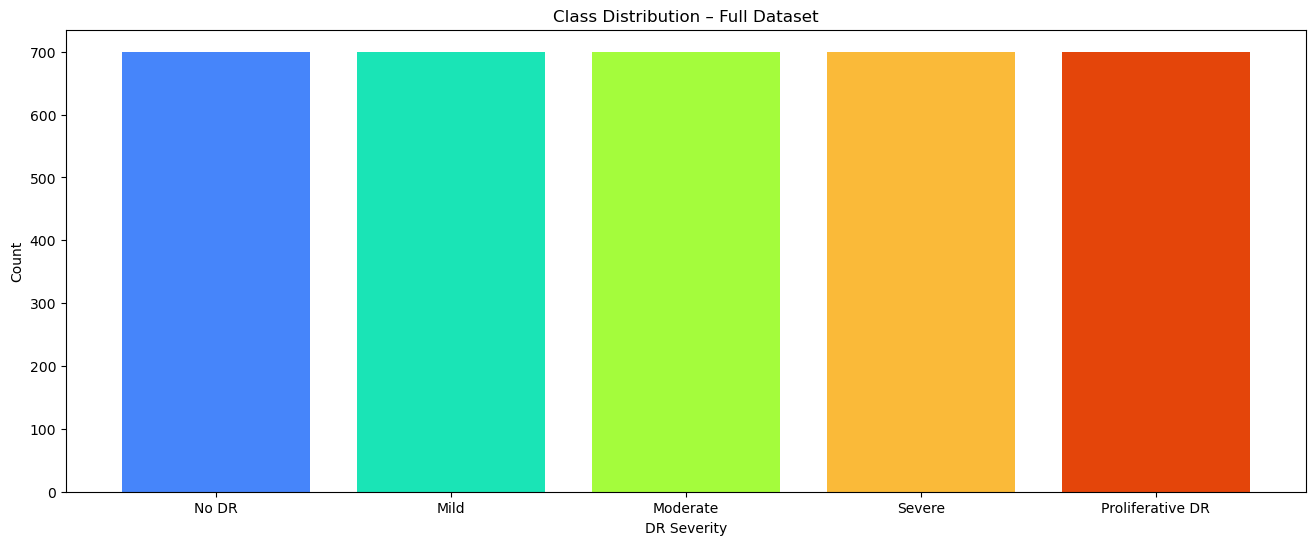

In [ ]:
resnet_graham.get_size_per_catogery()

We observe that for the training sample, all classes are balanced.

Next, we observe the images sizes to verify they are all of the same size

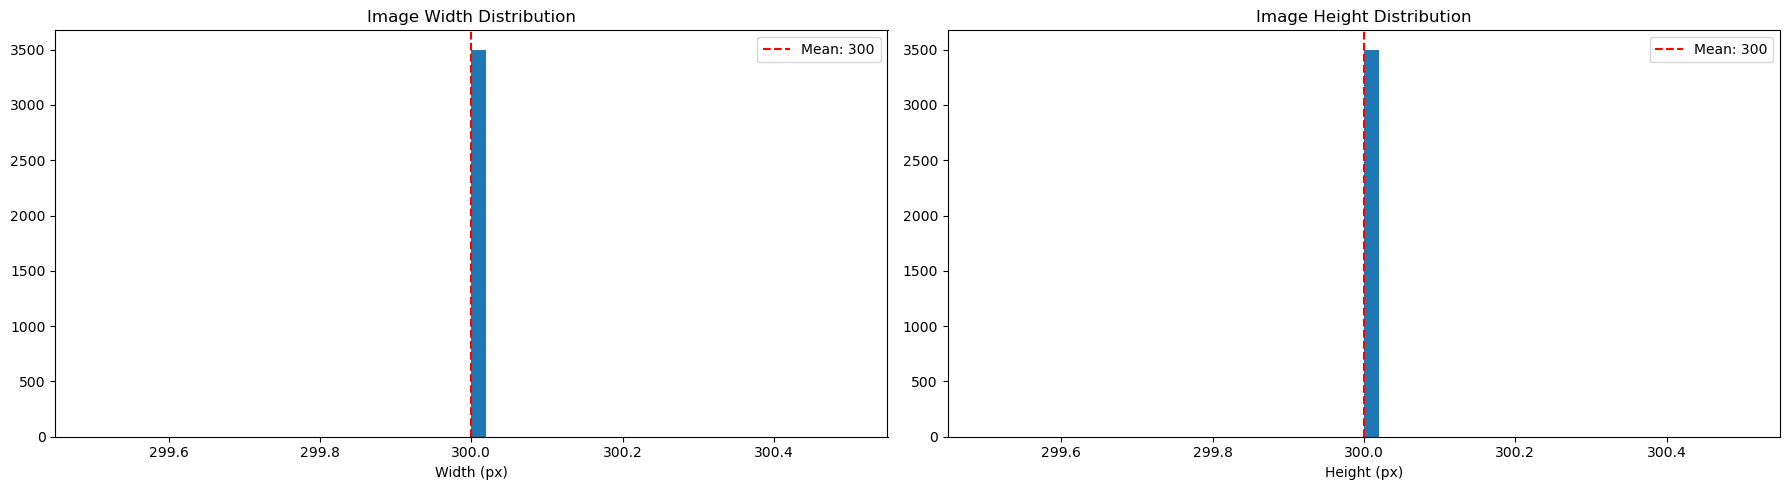

Width is similar accross all images
Height is similar accross all images


In [ ]:
resnet_graham.get_images_properties()

All images are of the same size

**Preprocessing**

To improve performances of the model, several transformations are applied to the images

### 1. Black Border Cropping (the function was inspired from Ben Trevett's notebook)
This step removes those irrelevant regions by:
- Converting the image to grayscale 
- Creating a mask of pixels above a brightness threshold (cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
- Extracting the bounding box around the retinal region

### 2. Gamma Correction 
This transformation adjusts image brightness and contrast in a nonlinear way with rendering dark regions more visible (central retina (foculae) appears to be brighter) and overexposed areas are slightly corrected. This will also standardize lighting differences across eyes and cameras

### 3. Ben Graham Preprocessing
This technique and the next is described in Nahiduzzaman et al.(2021) "Hybrid CNN-SVD based prominent feature extraction and selection for grading diabetic retinopathy using extreme learning machine algorithm". IEEE Access, 9, 152261-152274.

In this notebook, after cropping black borders and applying gamma correction, the function subtracts a heavily blurred version of the image from the original to enhances local structures (lesions, microaneurysms) and reduces global illumination effects

### 4. CLAHE Preprocessing (Contrast Limited Adaptive Histogram Equalization)
Contrast Limited Adaptive Histogram Equalization (CLAHE) improves local contrast while controlling noise amplification.

Like Ben Graham, the notebook apply cropping black borders and applying gamma correction. Next, this function convert image to LAB color space
and next apply CLAHE to the L-channel (brightness). Finally, the function recombine channels and convert back to RGB


The results are shown below

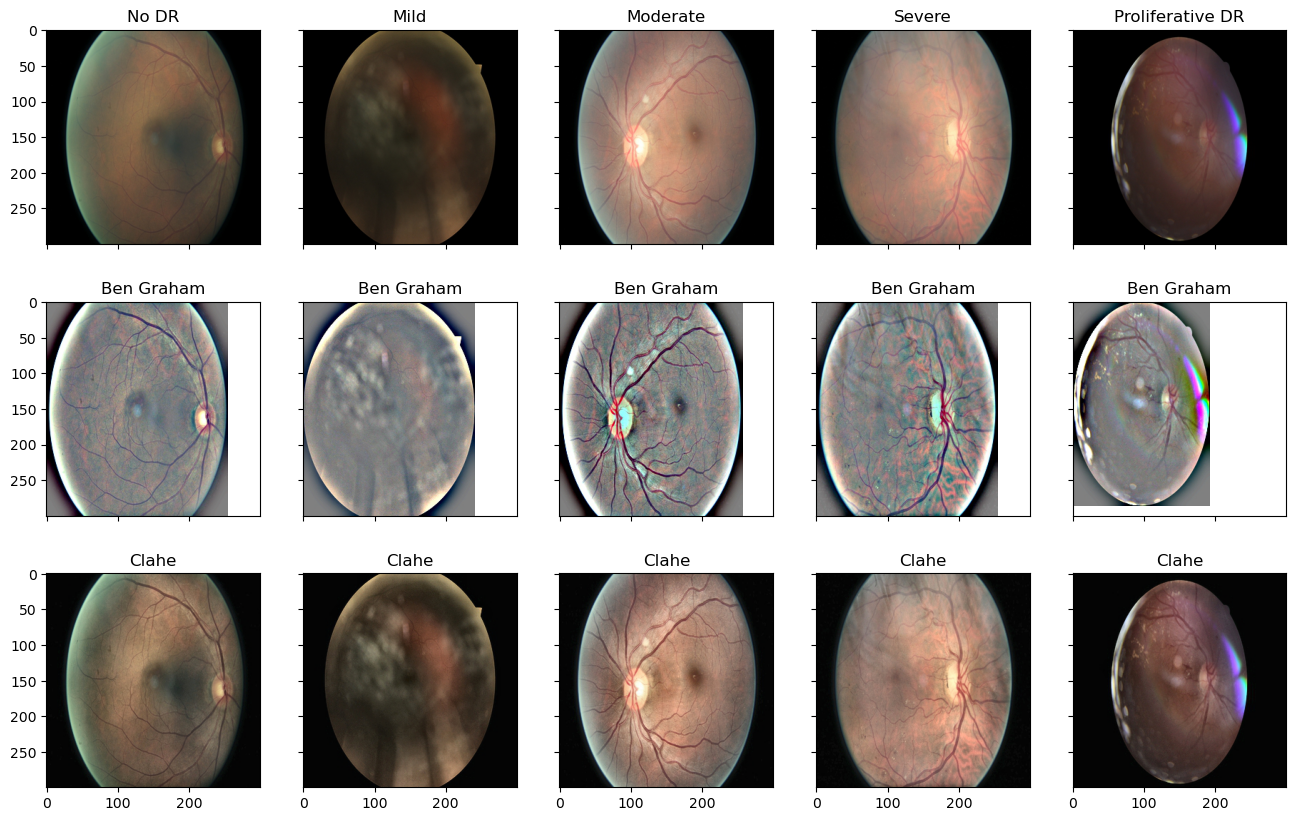

In [ ]:
resnet_graham.plot_comparison_with_non_processed()

We observe that CLAHE preserves the original color structure of the retinal image. After enhancement, notable features remain in a natural color space, which helps maintain clinically meaningful color information. 

On the opposite, Ben Graham don't preserve original colors. The transformation focuses on enhancing local contrast by subtracting a blurred version of the image outputting a grayscale image. This removes much of the color information but strongly emphasizes structures.


**Model Tuning**

The training pipeline is built inside the `Image_Processing` class and is responsible for data augmentation, model training, evaluation, and hyperparameter tuning for the ResNet50-based system.

### 1. Data Transformations (Image Augmentation)

The pipeline add random horizontal and vertical flip and rotation (±30°) to the image. Next, color jitter (brightness, contrast, saturation, hue) is added, with Random affine transformations (translation + scaling)
Finally, normalization is applied to the images 

### 2. Training Loop

Each epoch includes a Loss computation using cross-entropy, a backpropagation with mixed precision (`autocast`).
Furthermore, gradient clipping (to stabilize training) is applied with optimizer step using AdamW and accuracy tracking

### 3. Training the model

To train the model, the class applies CrossEntropyLoss with class weights (that are equal to 1), AdamW optimizer Cosine Annealing learning rate scheduler

The training includes an early stopping based on Cohen’s Kappa and mixed precision training (GradScaler)

The key metric **Quadratic Weighted Kappa (QWK)** is used as the main evaluation metric because it better reflects ordinal classification performance (important for DR severity levels).

### 5. Hyperparameter Tuning 

This function performs grid-style hyperparameter search as it iterates over different configurations of:
  - Learning rate
  - Weight decay

In [ ]:
import itertools

config = [
    {'lr':lr,'weight_decay':wd}for lr,wd in itertools.product([1e-5, 3e-5, 5e-5],[1e-5, 1e-4, 1e-3])
]
resnet_graham.tune_model("model_resnet50", config)


Hyperparameter search for ResNet (9 configs x 15 epochs):
----------------------------------------------------------------------

Config 1/9: {'lr': 1e-05, 'weight_decay': 1e-05}

  Training model_resnet50
  LR=1e-05, WD=1e-05, Epochs=15, Patience=4


100%|██████████| 87/87 [00:50<00:00,  1.72it/s]


  Epoch 01/15 | Train Loss: 1.5855 Acc: 0.2716 | Val Loss: 1.5480 Acc: 0.3429 QWK: 0.4257 | 60.8s


100%|██████████| 87/87 [00:38<00:00,  2.26it/s]


  Epoch 02/15 | Train Loss: 1.5011 Acc: 0.3696 | Val Loss: 1.4500 Acc: 0.3814 QWK: 0.5228 | 48.4s


...

  Epoch 03/15 | Train Loss: 0.0691 Acc: 0.9810 | Val Loss: 3.2856 Acc: 0.4829 QWK: 0.6792 | 47.9s


100%|██████████| 87/87 [00:36<00:00,  2.36it/s]


  Epoch 04/15 | Train Loss: 0.0641 Acc: 0.9781 | Val Loss: 3.4587 Acc: 0.4586 QWK: 0.6510 | 46.6s


100%|██████████| 87/87 [00:37<00:00,  2.35it/s]


  Epoch 05/15 | Train Loss: 0.0475 Acc: 0.9835 | Val Loss: 3.3782 Acc: 0.4614 QWK: 0.6673 | 46.9s
  Early stopping triggered at epoch 5

  Best epoch: 1 with QWK = 0.6812


Hyperparameter Search Results ResNet:
     lr  weight_decay  cohen_kappa
0.00001       0.00001     0.706341
0.00001       0.00010     0.700233
0.00001       0.00100     0.693042
0.00003       0.00001     0.679793
0.00003       0.00010     0.697674
0.00003       0.00100     0.710398
0.00005       0.00001     0.715875
0.00005       0.00010     0.707292
0.00005       0.00100     0.681235

Best hyperparameters for ResNet_Ben_Graham: {'lr': 5e-05, 'weight_decay': 1e-05, 'cohen_kappa': 0.7158746208291203}


In [3]:
resnet_graham_model, resnet_graham_history, resnet_graham_best_kappa = resnet_graham.train_model("model_resnet50",epochs=30,best_model=True,chosen_transformation="Ben_Graham")


  Training model_resnet50
  LR=5e-05, WD=1e-05, Epochs=30, Patience=4


100%|██████████| 87/87 [00:36<00:00,  2.37it/s]


  Epoch 01/30 | Train Loss: 1.4176 Acc: 0.4005 | Val Loss: 1.2635 Acc: 0.4300 QWK: 0.6176 | 46.7s


100%|██████████| 87/87 [00:38<00:00,  2.27it/s]


  Epoch 02/30 | Train Loss: 1.0025 Acc: 0.6031 | Val Loss: 1.1933 Acc: 0.4771 QWK: 0.6992 | 47.7s


...

  Epoch 07/30 | Train Loss: 0.1134 Acc: 0.9741 | Val Loss: 1.6667 Acc: 0.4700 QWK: 0.6712 | 43.0s


100%|██████████| 87/87 [00:35<00:00,  2.45it/s]


  Epoch 08/30 | Train Loss: 0.0733 Acc: 0.9802 | Val Loss: 1.6564 Acc: 0.4857 QWK: 0.6885 | 45.0s


100%|██████████| 87/87 [00:34<00:00,  2.49it/s]


  Epoch 09/30 | Train Loss: 0.0571 Acc: 0.9842 | Val Loss: 1.7389 Acc: 0.5157 QWK: 0.7231 | 43.7s
  Early stopping triggered at epoch 9

  Best epoch: 5 with QWK = 0.7244
ResNet50 model saved to ./outputs/tensors/ResNet_Ben_Graham_best.pth


In [ ]:
resnet_graham.evaluate_model("model_resnet50")


  model_resnet50 - Evaluation Results
  Validation Loss:     1.3183
  Validation Accuracy: 0.4986
  Quadratic W. Kappa:  0.7244
  Macro F1-Score:      0.5014
  Weighted F1-Score:   0.5014


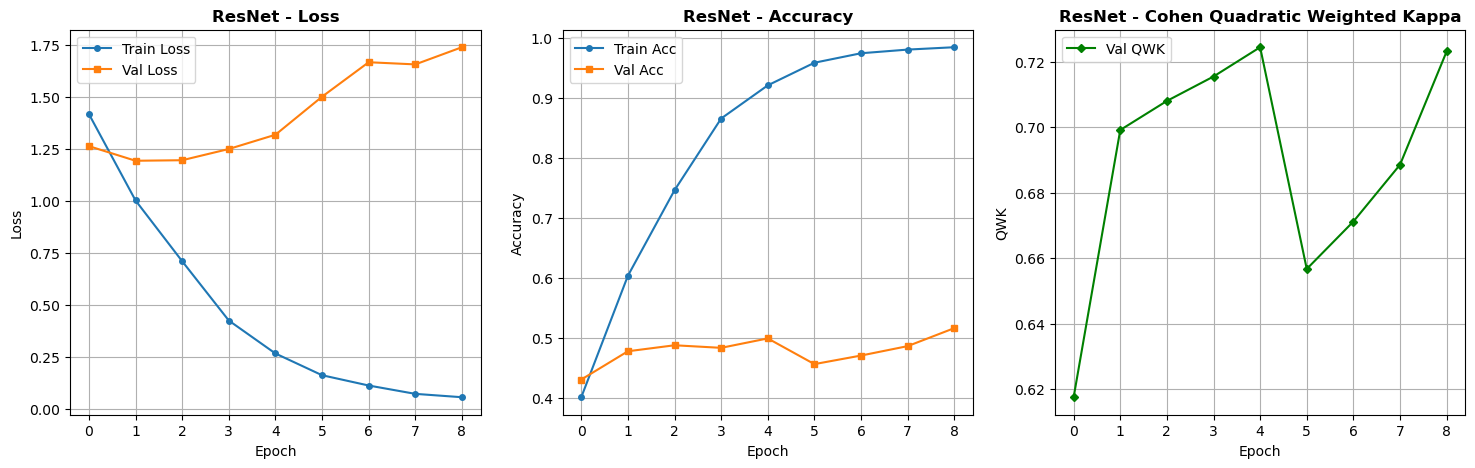

In [ ]:
resnet_graham.plot_training_diagnosis(resnet_graham_history,'model_resnet50')

TypeError: unsupported format string passed to tuple.__format__

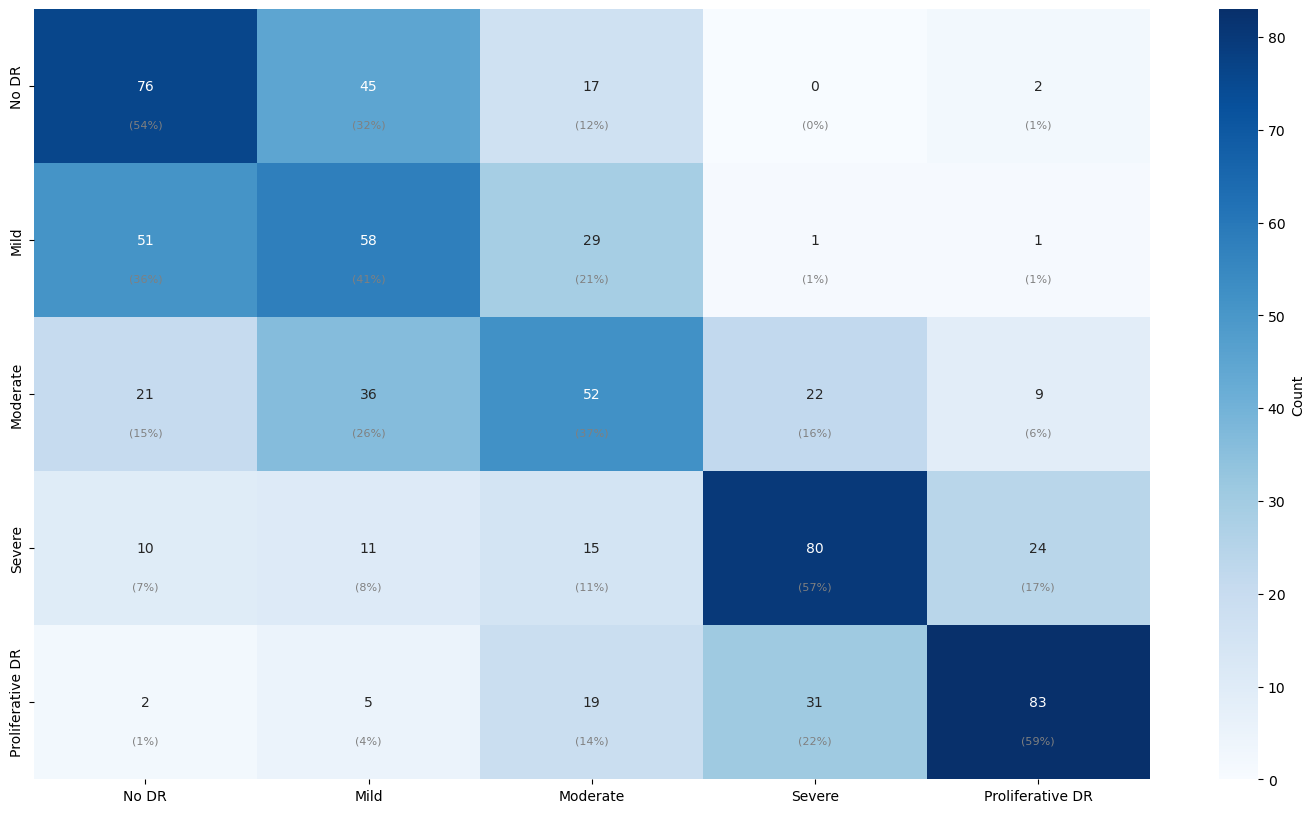

In [ ]:
resnet_graham.compute_confusion_matrix("model_resnet50")

In [ ]:
resnet_graham.compute_reports("model_resnet50")

  Classification Report - ResNet
                  precision    recall  f1-score   support

           No DR     0.4750    0.5429    0.5067       140
            Mild     0.3742    0.4143    0.3932       140
        Moderate     0.3939    0.3714    0.3824       140
          Severe     0.5970    0.5714    0.5839       140
Proliferative DR     0.6975    0.5929    0.6409       140

        accuracy                         0.4986       700
       macro avg     0.5075    0.4986    0.5014       700
    weighted avg     0.5075    0.4986    0.5014       700



In [ ]:
eff_resnet_graham_model, eff_resnet_graham_history, eff_resnet_graham_best_kappa = resnet_graham.train_model("model_efficientnet_b3",epochs=30,best_model=True,chosen_transformation="Ben_Graham")

In [ ]:
resnet_graham.evaluate_model("model_efficientnet_b3")

In [ ]:
resnet_graham.plot_training_diagnosis(eff_resnet_graham_history,'model_efficientnet_b3')

In [ ]:
resnet_graham.compute_confusion_matrix("model_efficientnet_b3")

In [ ]:
resnet_graham.compute_reports("model_efficientnet_b3")

**CLahe**

In [ ]:
resnet_clahe.tune_model("model_resnet50", config)

In [ ]:
resnet_clahe_model, resnet_clahe_history, resnet_clahe_best_kappa = resnet_clahe.train_model("model_resnet50",epochs=30,best_model=True,chosen_transformation="Clahe")

In [ ]:
resnet_clahe.evaluate_model("model_resnet50")

In [ ]:
resnet_clahe.plot_training_diagnosis(resnet_clahe_history,'model_resnet50')

In [ ]:
resnet_clahe.compute_confusion_matrix("model_resnet50")

In [ ]:
resnet_clahe.compute_reports("model_resnet50")

For Efficient Model

In [ ]:
resnet_clahe_effi_model, resnet_clahe_effi_history, resnet_clahe_effi_best_kappa = resnet_clahe.train_model("model_efficientnet_b3",lr = resnet_clahe.best_params['lr'],weight_decay=resnet_clahe.best_params['weight_decay'],epochs=30,best_model=True)

AttributeError: 'ResNet50' object has no attribute 'best_params'

In [ ]:
resnet_clahe.evaluate_model("model_efficientnet_b3")

In [ ]:
resnet_clahe.plot_training_diagnosis(resnet_graham_history,'model_efficientnet_b3')

In [ ]:
resnet_clahe.compute_confusion_matrix("model_efficientnet_b3")

In [ ]:
resnet_clahe.compute_reports("model_efficientnet_b3")

**Prediction**



In [ ]:

prediction_graham = Predict_with_model(resnet_graham_model,'./Dataset/test/')

results = prediction_graham.predict_from_images()
results

In [ ]:
results.to_csv('./outputs/report/results_graham_net50.csv',index=False)